In [2]:
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "4"


import numpy as np 
from phentax.waveform import IMRPhenomTHM
import matplotlib.pyplot as plt
%load_ext autoreload
import scienceplots
import numpy as np
import jax.numpy as jnp
import scipy 
import jax

plt.style.use(['science'])
plt.rcParams.update({'font.size': 20})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Setting up waveform parameters
chi1 = 0.9
chi2 = 0.3
distance = 500.0
inclination = jnp.pi / 3.0
phi_ref = 0.0
psi = 0.0
f_ref = 1.e-4

m1 = 5.e+6
m2 = 1.e+6
f_min = f_ref
delta_t = 5

In [4]:
tlowfit = True
tol = 1e-12

imr = IMRPhenomTHM(
    higher_modes='all',
    include_negative_modes=True,
    t_low_fit=tlowfit,
    coarse_grain=False,
    atol=tol,
    rtol=tol,
)

# First of all, compute waveform $h_+(t)$ and $h_{\times}(t)$ using the normal time-domain method and then directly SFT

In [5]:
# Compute h_+(t) and h_x(t)
times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
        m1,
        m2,
        chi1,
        chi2,
        distance,
        phi_ref,
        f_ref,
        f_min,
        inclination,
        psi,
        delta_t=delta_t,        
    )

In [6]:
times.squeeze()[mask.squeeze()][0]/(365.25*24*3600)
# Shifting times to be positive
times_shifted =times.squeeze() - times.squeeze()[0]

Text(0, 0.5, '$h_+(t)$')

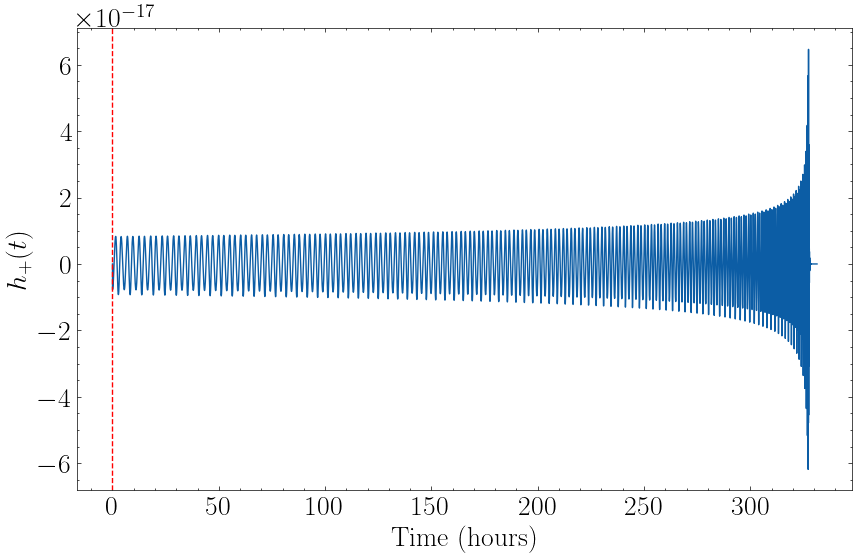

In [7]:
plt.figure(figsize=(10,6))
plt.plot(times_shifted[::10]/(3600), h_plus.squeeze()[::10], label='h_plus')
plt.axvline(times_shifted[mask.squeeze()][0]/(3600), label='Fitted Region',linestyle='--',color='r')
plt.xlabel('Time (hours)')
plt.ylabel(r'$h_+(t)$')

In [8]:

def setup_tf_grid(T,
                  dt, 
                  dT):
    '''
    Sets up time-frequency grid for time-frequency domain calculations. 

    Args:
        T (float): Total observation time (s) 
        dt (float): Sampling time (s)
        dT (float): Time segment duration (s)
    Returns:
        t_grid (jax.numpy.array): Time grid (s)
        f_grid (jax.numpy.array): Frequency grid (Hz)
    '''

    print("Setting up time-frequency grid...")
    print(f"Total observation time: {T} s")

    nT = int(T/dT) # length of each time chunk
    print(f"Number of time segments: {nT}")

    t_grid = jnp.arange(nT)*dT
    # Frequency resolution 
    dF =f_min= (1/dT)
    f_max = 1/(dt)/ 2 # Nyquist frequency 

    nF = int((f_max - f_min) / dF) + 1 # frequency bins per segment
    
    # Frequency grid (neglecting DC component)
    f_grid = jnp.arange(1,nF+1) * dF  # segment frequencies
    # Time grid
    t_grid = jnp.arange(nT,dtype=float) * dT

    return(t_grid,f_grid)
t_grid, f_grid = setup_tf_grid(T=times_shifted[mask.squeeze()][-1],dt = delta_t, dT = 12*3600)


Setting up time-frequency grid...
Total observation time: 1192966.4728429238 s
Number of time segments: 27


# Compute SFT 

In [9]:
signal = h_plus.squeeze()

data_tf_plus = np.zeros((t_grid.shape[0], f_grid.shape[0]), dtype=complex)
for i in range(t_grid.shape[0]-1):
    
    t0 = t_grid[i]
    t1 = t_grid[i+1]
    times = times_shifted[(times_shifted >= t0) & (times_shifted < t1)]
    segment = signal[(times_shifted >= t0) & (times_shifted < t1)]

    # Apply a window function to the segment to mitigate spectral leakage. Here we use a Tukey window with a small alpha for minimal tapering.
    win = scipy.signal.windows.tukey(np.sum((times_shifted >= t0) & (times_shifted < t1)), alpha=0.01)
    # Do something with the segment, e.g., compute its FFT

    fft_segment = np.fft.rfft(segment*win)*delta_t
    data_tf_plus[i, :] = fft_segment[1: ]





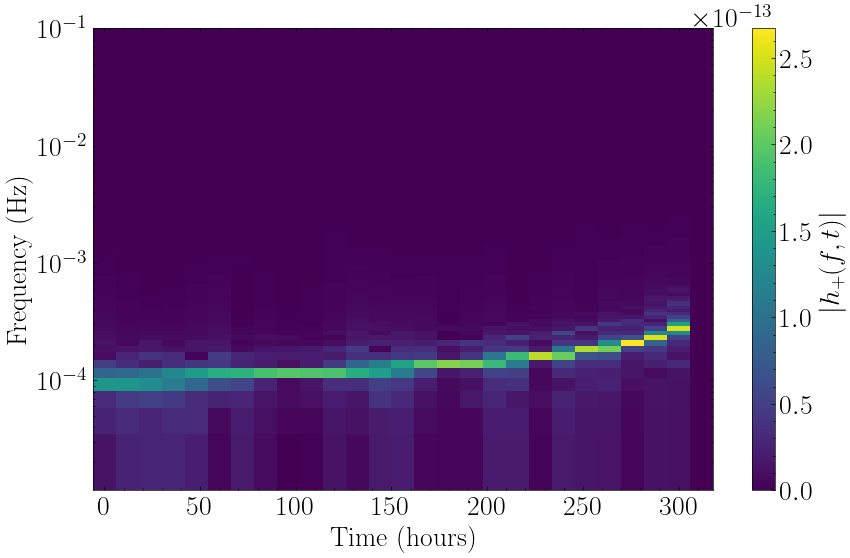

In [ ]:
plt.figure(figsize=(10,6))
plt.pcolormesh(t_grid/3600, f_grid, jnp.abs(data_tf_plus).T, shading='auto')
plt.semilogy()
plt.colorbar(label='$|h_+(f,t)|$')
plt.xlabel('Time (hours)')
plt.ylabel('Frequency (Hz)')
# plt.savefig('data_tf_plus.pdf')

# Effectively the plot above is what we are trying to reproduce.

# Compute directly using SFT kernel:

In [11]:
%autoreload 2
from phentax.waveform_tf import IMRPhenomTHM_TF

tlowfit = True
tol = 1e-12

imr_tf = IMRPhenomTHM_TF(
    higher_modes='all',
    include_negative_modes=True,
    t_low_fit=tlowfit,
    coarse_grain=False,
    atol=tol,
    rtol=tol,
)
# Batching with 100 of the same waveform for now. 
tf_grid = imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray([m1]*100),
            jnp.asarray([m2]*100),
            jnp.asarray([chi1]*100),
            jnp.asarray([chi2]*100),
            jnp.asarray([distance]*100),
            jnp.asarray([phi_ref]*100),
            f_ref,
            f_min,
            jnp.asarray([inclination]*100),
            jnp.asarray([psi]*100),
            delta_t,
            closest_f_bins=10)


/data/diganta/THM_TF/venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


# Sanity check shape (# num sources, # num times, # num freqs)

In [12]:
tf_grid[0].shape # [0] is the h_plus component, [1] is the h_cross component. 

(100, 27, 4320)

In [13]:
bytes_on_device = tf_grid[0].size * tf_grid[0].dtype.itemsize
print("Memory usage of (whole) tf_grid on device:")
print(bytes_on_device / 1024**2, "MB")


Memory usage of (whole) tf_grid on device:
177.978515625 MB


In [14]:
tf_grid[0].shape

(100, 27, 4320)

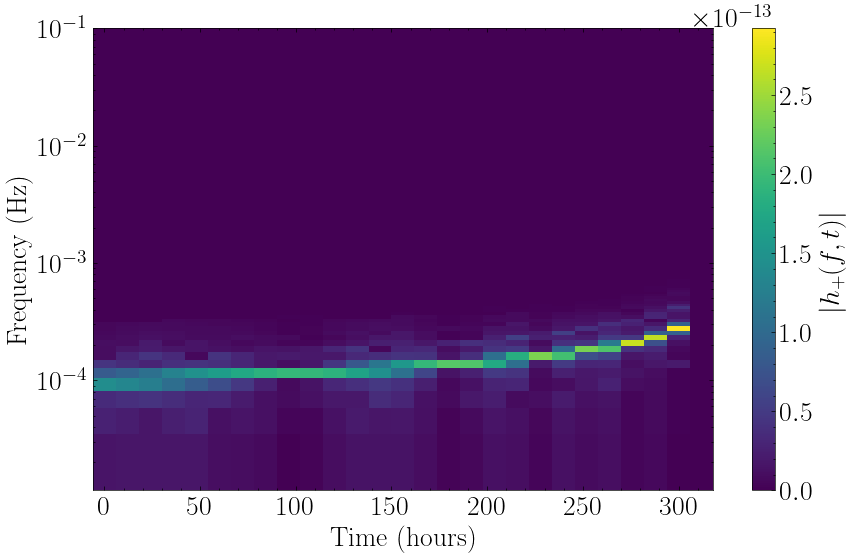

In [ ]:
plt.figure(figsize=(10,6))
plt.pcolormesh(t_grid/3600, f_grid, jnp.abs(tf_grid[0][0]).T, shading='auto')
plt.semilogy()
plt.colorbar(label=r'$|h_{+}(f,t)|$')
plt.xlabel('Time (hours)')
plt.ylabel('Frequency (Hz)') 
# plt.savefig('Fresnel_h_plus.pdf')   
plt.show()

# Compare with the 'True' SFT'd result: 


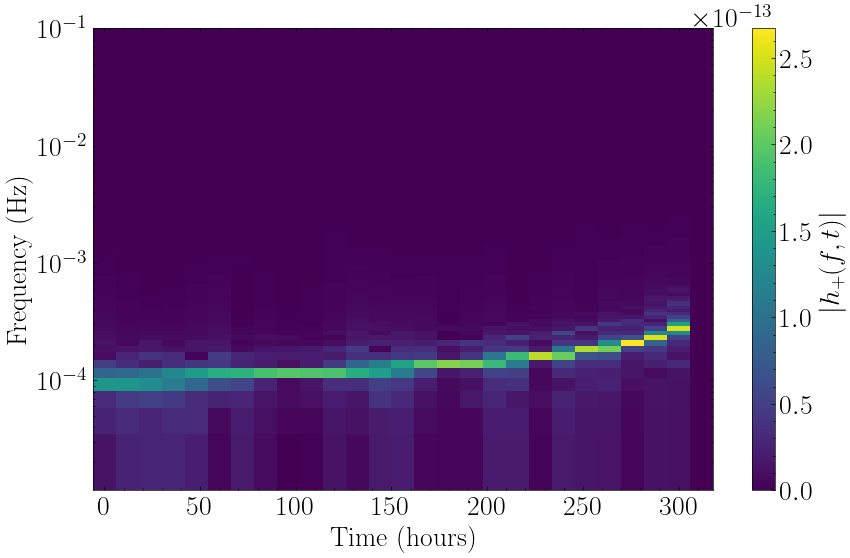

In [ ]:
plt.figure(figsize=(10,6))
plt.pcolormesh(t_grid/3600, f_grid, jnp.abs(data_tf_plus).T, shading='auto')
plt.semilogy()
plt.colorbar(label='$|h_+(f,t)|$')
plt.xlabel('Time (hours)')
plt.ylabel('Frequency (Hz)')
# plt.savefig('SFT_h_plus.pdf')   
plt.show()


# Validate 'optimal SNRs' (basically validting the inner product no PSD) so not real optimal SNR

In [17]:
# SNRs
print('SNR (Fresnel):', jnp.abs(tf_grid[0][0]*tf_grid[0][0].conj()).sum())

print('SNR (data):', jnp.abs(data_tf_plus*data_tf_plus.conj()).sum())


SNR (Fresnel): 1.2970882819089752e-24
SNR (data): 1.3586169736312311e-24


# But what about accuracy? Let's compare the Fresnel-TF with the SFT and see how well they match.

In [19]:
print('Overall match (h_plus): ', jnp.abs(tf_grid[0][0]*data_tf_plus.conj()).sum()/jnp.sqrt(jnp.abs(data_tf_plus*data_tf_plus.conj()).sum()*jnp.abs(tf_grid[0][0]*tf_grid[0][0].conj()).sum()))
print('Overall match (h_cross): ', jnp.abs(tf_grid[1][0]*data_tf_plus.conj()).sum()/jnp.sqrt(jnp.abs(data_tf_plus*data_tf_plus.conj()).sum()*jnp.abs(tf_grid[1][0]*tf_grid[1][0].conj()).sum()))

Overall match (h_plus):  0.9895050111276119
Overall match (h_cross):  0.9893817013330606


# We know this basis for the waveform will fail as we get closer to merger, lets plot the cumulative match as a function of time to see if that is where we are actually failing... 

In [20]:
cumulative_match = []
for time_index in range(t_grid.shape[0]):
    cumulative_match.append(jnp.real(tf_grid[0][0][time_index,:]*data_tf_plus[time_index,:].conj()).sum()/jnp.sqrt(jnp.abs(data_tf_plus[time_index,:]*data_tf_plus[time_index,:].conj()).sum()*jnp.abs(tf_grid[0][0][time_index,:]*tf_grid[0][0][time_index,:].conj()).sum()))

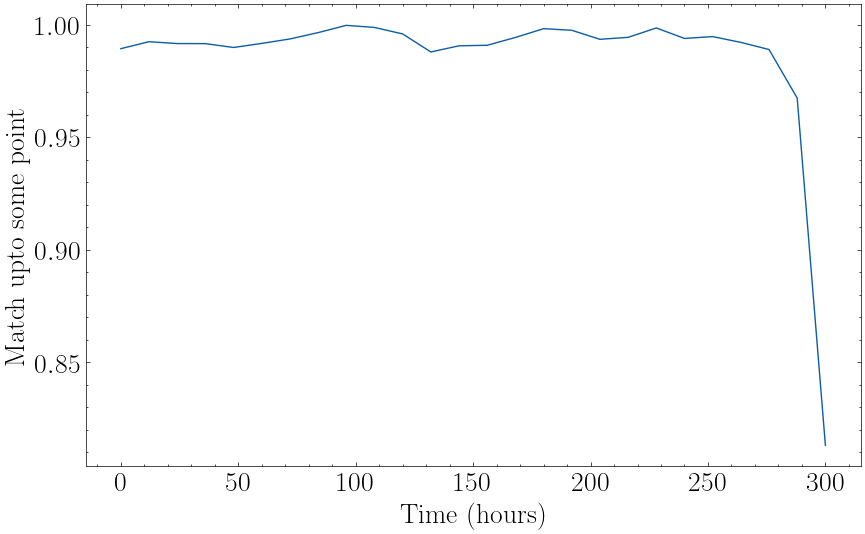

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(t_grid/3600, cumulative_match)
plt.xlabel('Time (hours)')
plt.ylabel('Match upto some point')
# plt.savefig('cumulative_match.png')
plt.show()



# Need to investigate why the match is going up and down, maybe there is some intuition for this, will need to see! 

# Timing (I am pretty sure this is an upper limit on the cost of the likelihood because we are not doing direct summation, there is a huge cost associated with actually placing the waveforms in the structure of a unique TF grid per source)

In [27]:
%%timeit 
jax.block_until_ready(imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray([m1]*100),
            jnp.asarray([m2]*100),
            jnp.asarray([chi1]*100),
            jnp.asarray([chi2]*100),
            jnp.asarray([distance]*100),
            jnp.asarray([phi_ref]*100),
            f_ref,
            f_min,
            jnp.asarray([inclination]*100),
            jnp.asarray([psi]*100),
            delta_t,
            closest_f_bins=10))


13.3 ms ± 251 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
# pre jitting for 2000 batch size.
tf_grid = imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray([m1]*2000),
            jnp.asarray([m2]*2000),
            jnp.asarray([chi1]*2000),
            jnp.asarray([chi2]*2000),
            jnp.asarray([distance]*2000),
            jnp.asarray([phi_ref]*2000),
            f_ref,
            f_min,
            jnp.asarray([inclination]*2000),
            jnp.asarray([psi]*2000),
            delta_t,
            closest_f_bins=10)

In [29]:
%%timeit 
jax.block_until_ready(imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray([m1]*2000),
            jnp.asarray([m2]*2000),
            jnp.asarray([chi1]*2000),
            jnp.asarray([chi2]*2000),
            jnp.asarray([distance]*2000),
            jnp.asarray([phi_ref]*2000),
            f_ref,
            f_min,
            jnp.asarray([inclination]*2000),
            jnp.asarray([psi]*2000),
            delta_t,
            closest_f_bins=10))


88.1 ms ± 455 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [30]:
88*1.e-3/2000

4.4e-05

# 44 $\mu\rm{s}$ per waveform, and this is the upper limit cost ! (Relatively little active optimisation has been done to make this implementation super fast so far as well)


# Next things to do/try: 
#   - Response (I have it finished, need to optimise it a bit and make it batchable)
#   - Direct summation (this will likely be the thing that reduces memory footprint significantly and allows for ludicrous batching, way more than what we do now here) 

# Sanity check to ensure changing the parameters a bit does not kill timings 

In [31]:

tf_grid = imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray(np.random.normal(size=100,scale=20)+ m1),
            jnp.asarray([m2]*100),
            jnp.asarray([chi1]*100),
            jnp.asarray([chi2]*100),
            jnp.asarray([distance]*100),
            jnp.asarray([phi_ref]*100),
            f_ref,
            f_min,
            jnp.asarray([inclination]*100),
            jnp.asarray([psi]*100),
            delta_t,
            closest_f_bins=10)


In [32]:
%%timeit 
jax.block_until_ready(imr_tf.get_tf_fresnel_waveform_vanilla_TF(t_grid,
            f_grid,
            jnp.asarray(np.random.normal(size=100,scale=20)+ m1),
            jnp.asarray([m2]*100),
            jnp.asarray([chi1]*100),
            jnp.asarray([chi2]*100),
            jnp.asarray([distance]*100),
            jnp.asarray([phi_ref]*100),
            f_ref,
            f_min,
            jnp.asarray([inclination]*100),
            jnp.asarray([psi]*100),
            delta_t,
            closest_f_bins=10))


12 ms ± 131 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
